In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams.update({
    'image.origin' : 'lower'
})

import numpy as np
from scoobpy import utils, eye_doctor
from magpyx.dm import control, dmutils
from magpyx.utils import ImageStream


from skimage import draw

from matplotlib.colors import LogNorm, SymLogNorm

from poppy import zernike
import cupy as cp

from purepyindi import INDIClient
from purepyindi import SwitchState as SwitchState0
from purepyindi2 import IndiClient, SwitchState #INDIClient


/opt/conda/lib/python3.10/site-packages/cupyx/jit/_interface.py:173: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')


In [2]:
    
def move_relative(client, device, val):
    client[f'{device}.target'] = client[f'{device}.current'] + val

client0 = INDIClient('localhost', 7624)
client0.start()

client = IndiClient()
client.connect()
client.get_properties()

INFO:purepyindi2.transports:Connected to localhost:7624


In [154]:
move_relative(client, 'stagepiezo.stagepupil_y_pos', 2) # -34378L

In [132]:
move_relative(client, 'stagepiezo.stagepupil_x_pos', 2) # -34378L

In [3]:
# connect to DM channel
dm = utils.connect_to_dmshmim(channel='dm00disp')
dm2 = utils.connect_to_dmshmim(channel='dm00disp02')
dm1 = utils.connect_to_dmshmim(channel='dm00disp01')
dm0 = utils.connect_to_dmshmim(channel='dm00disp00')
pupilcam = ImageStream('campupil')

In [4]:
dm_map, dm_mask = utils.get_kilo_map_mask()

In [5]:
zbasis = cp.asnumpy(zernike.arbitrary_basis(cp.array(dm_mask), outside=0))

In [29]:
amps = np.linspace(-0.075, 0.075, num=30)

In [30]:
ims = []
for i, amp in enumerate(amps):
    print(f'{i+1}/{len(amps)}, amp: {amp:.3f}')
    cmd = amp * zbasis[3]
    dm2.write(cmd)
    im = np.mean(pupilcam.grab_after(40, nwait=4),axis=0)
    ims.append(im)
dm2.write(cmd*0)
ims = np.asarray(ims)

1/30, amp: -0.075
2/30, amp: -0.070
3/30, amp: -0.065
4/30, amp: -0.059
5/30, amp: -0.054
6/30, amp: -0.049
7/30, amp: -0.044
8/30, amp: -0.039
9/30, amp: -0.034
10/30, amp: -0.028
11/30, amp: -0.023
12/30, amp: -0.018
13/30, amp: -0.013
14/30, amp: -0.008
15/30, amp: -0.003
16/30, amp: 0.003
17/30, amp: 0.008
18/30, amp: 0.013
19/30, amp: 0.018
20/30, amp: 0.023
21/30, amp: 0.028
22/30, amp: 0.034
23/30, amp: 0.039
24/30, amp: 0.044
25/30, amp: 0.049
26/30, amp: 0.054
27/30, amp: 0.059
28/30, amp: 0.065
29/30, amp: 0.070
30/30, amp: 0.075


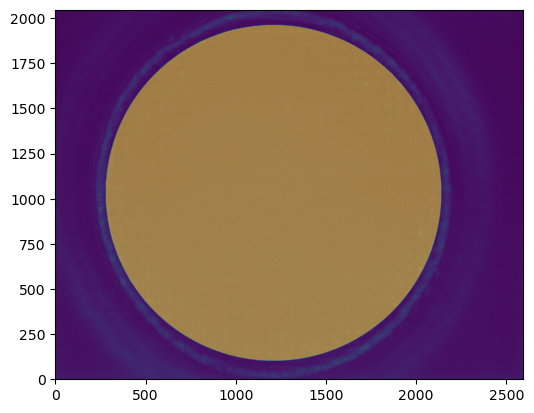

In [31]:
idy, idx = draw.disk((1030,1210), 930)
pupil_mask = np.zeros(ims[-1].shape, dtype=bool)
pupil_mask[idy, idx] = 1

plt.imshow(ims[15])
plt.imshow(pupil_mask, alpha=0.5)

Text(0, 0.5, '$\\sum$ pupil')

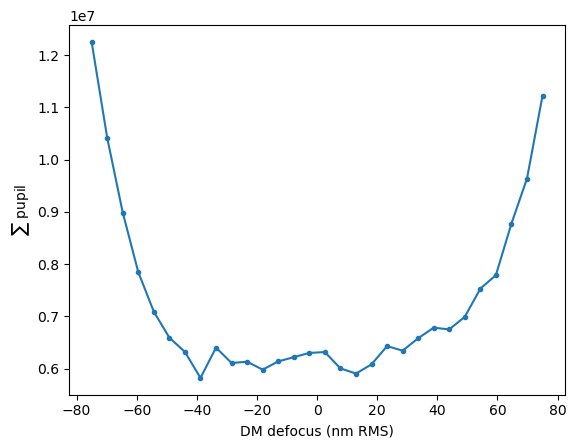

In [32]:
signal = np.sum(ims*pupil_mask, axis=(-2,-1))
plt.plot(amps*1e3, signal, marker='.')
#plt.plot(amps*1e3, 2e12*amps**4 + 2.1e7, marker='.')
plt.xlabel('DM defocus (nm RMS)')
plt.ylabel('$\sum$ pupil')